In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

# Базовая работа с изображением

In [16]:
image = cv2.imread('sar_2_color.jpg')

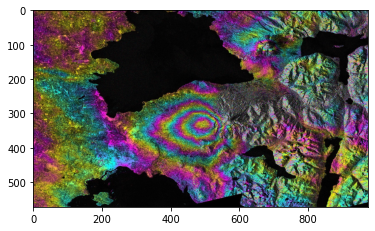

In [ ]:
plt.imshow(image)

In [18]:
image.shape # h,w,c

(572, 974, 3)

In [19]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [20]:
# ROI
img_roi = image[100:200, 500:700]

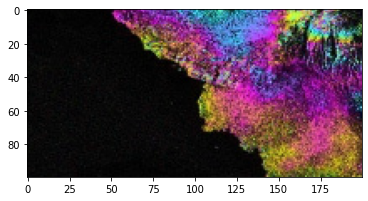

In [21]:
plt.imshow(img_roi)

In [22]:
b,g,r = cv2.split(image)

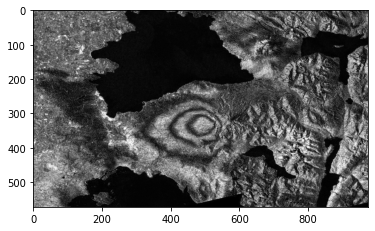

In [23]:
plt.imshow(b, cmap = 'gray')

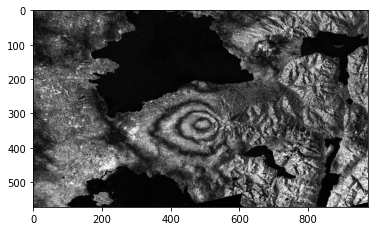

In [24]:
plt.imshow(g, cmap = 'gray')

In [25]:
# alternative approach
b = image[:,:,0]

In [26]:
import copy

image2 = copy.deepcopy(image)

In [27]:
image2[50:100,50:100] = [0,0,0]

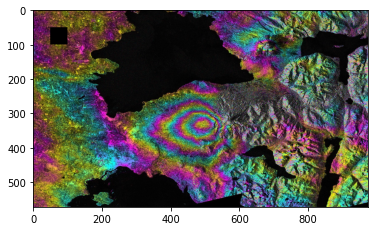

In [28]:
plt.imshow(image2)

In [29]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

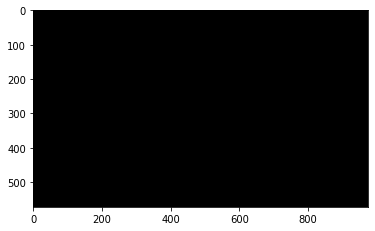

In [30]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [31]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [32]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [33]:
image_gray[0,0]

40

In [34]:
image_gray.shape

(572, 974)

In [35]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [36]:
image_hsv.shape

(572, 974, 3)

In [37]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [38]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [39]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [40]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [67]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

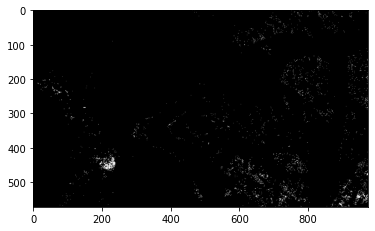

In [68]:
plt.imshow(thresh1, cmap='gray')

In [43]:
thresh1[thresh1==100].sum()

0

# Построение гистограммы

In [44]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

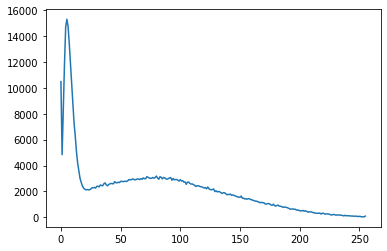

In [45]:
plt.plot(b_hist)

In [46]:
b_hist_cum = b_hist.cumsum()

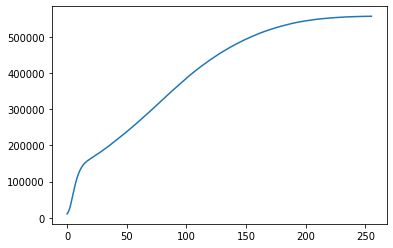

In [47]:
plt.plot(b_hist_cum)

In [49]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

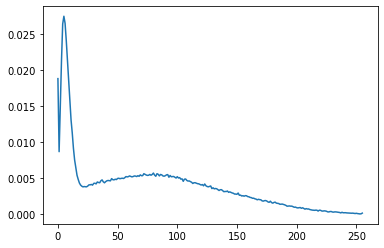

In [50]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [53]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


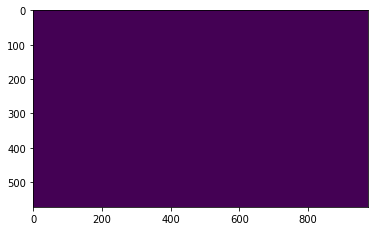

In [54]:
plt.imshow(diff)

In [55]:
mse = mean_squared_error(image_gray, image_gray)
mse

0.0

# Статистические характеристики изображений

In [56]:
mean = image_gray.mean()

In [57]:
std = image_gray.std()

In [58]:
print(mean,std)

67.41225535245043 52.016191875959635


In [60]:
eq_gray = cv2.equalizeHist(image_gray)

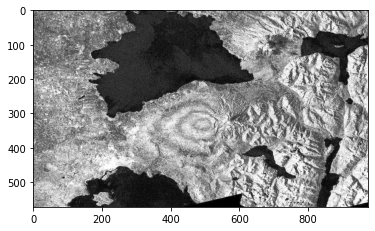

In [63]:
plt.imshow(eq_gray, cmap="gray")


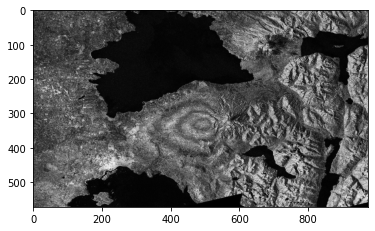

In [64]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


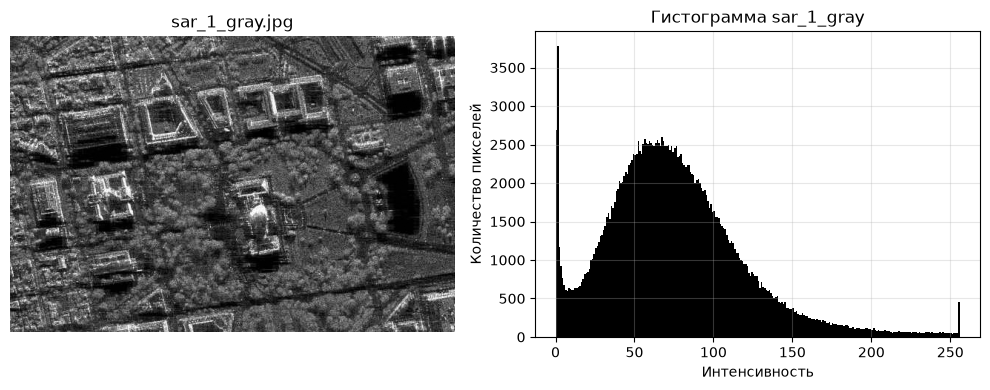

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка в оттенках серого
sar_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

# Построение гистограммы
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('sar_1_gray.jpg')
plt.axis('off')

plt.subplot(1, 2, 2)
# Подсчет гистограммы для значений 0..255
plt.hist(sar_gray.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Гистограмма sar_1_gray')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

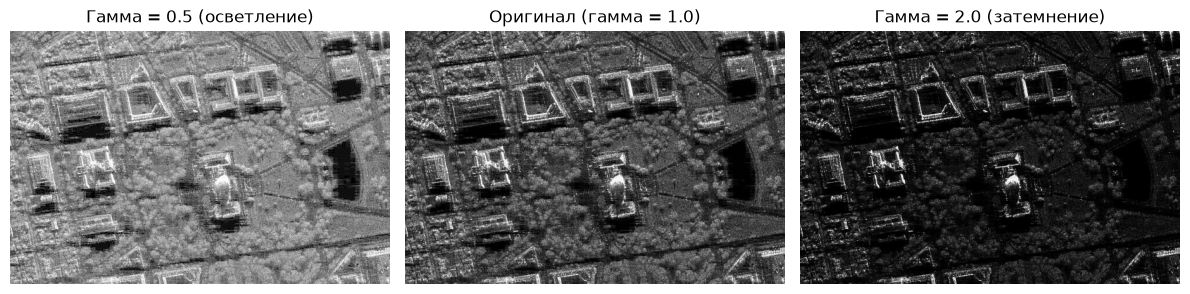

In [ ]:
def gamma_correction(img: np.ndarray, gamma: float) -> np.ndarray:
    # Нормирование к [0, 1], возводим в степень и масштабируем обратно в [0, 255]
    res = np.power(img / 255.0, gamma) * 255.0
    return np.clip(res, 0, 255).astype(np.uint8)

# Гамма < 1 (осветление) и Гамма > 1 (затемнение)
img_gamma_low = gamma_correction(sar_gray, gamma=0.5)
img_gamma_high = gamma_correction(sar_gray, gamma=2.0)

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_gamma_low, cmap='gray')
plt.title('Гамма = 0.5 (осветление)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sar_gray, cmap='gray')
plt.title('Оригинал (гамма = 1.0)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title('Гамма = 2.0 (затемнение)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from skimage.metrics import structural_similarity, mean_squared_error

# Сравнение с гаммой 0.5
mse_low = mean_squared_error(sar_gray, img_gamma_low)
ssim_low = structural_similarity(sar_gray, img_gamma_low)

# Сравнение с гаммой 2.0
mse_high = mean_squared_error(sar_gray, img_gamma_high)
ssim_high = structural_similarity(sar_gray, img_gamma_high)

print("--- Сравнение оригинала и гамма-фильтра ---")
print(f"Гамма 0.5 -> MSE: {mse_low:.2f}, SSIM: {ssim_low:.4f}")
print(f"Гамма 2.0 -> MSE: {mse_high:.2f}, SSIM: {ssim_high:.4f}")

--- Сравнение оригинала и гамма-фильтра ---
Гамма 0.5 -> MSE: 3250.43, SSIM: 0.7875
Гамма 2.0 -> MSE: 2383.76, SSIM: 0.5270


Оригинал:   Mean = 74.94, Std = 43.66
Эталон:     Mean = 127.03, Std = 74.27
Скоррект.:  Mean = 123.12, Std = 65.30


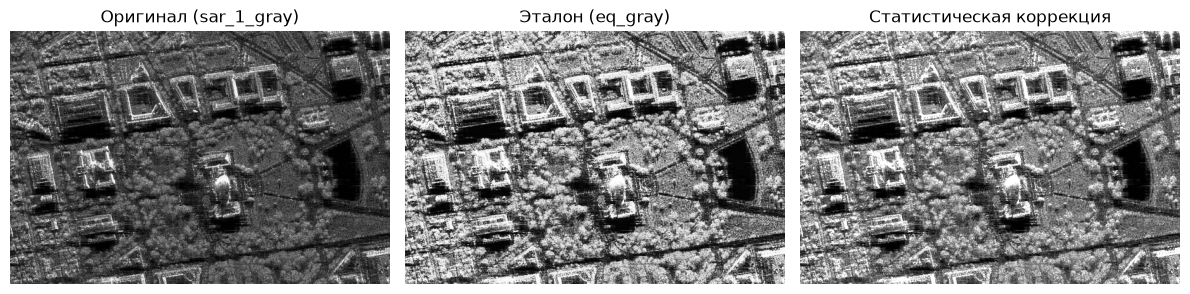

In [ ]:
# эквализированное изображение
eq_gray = cv2.equalizeHist(sar_gray)

# статистики (мат. ожидание и дисперсию/стд)
e_orig, d_orig = sar_gray.mean(), sar_gray.std()
e_donor, d_donor = eq_gray.mean(), eq_gray.std()

# статистическая коррекция
sar_gray_float = sar_gray.astype(np.float32)
stat_corrected = e_donor + (sar_gray_float - e_orig) * (d_donor / (d_orig + 1e-6))
stat_corrected = np.clip(stat_corrected, 0, 255).astype(np.uint8)

# Печать результатов и графики
print(f"Оригинал:   Mean = {e_orig:.2f}, Std = {d_orig:.2f}")
print(f"Эталон:     Mean = {e_donor:.2f}, Std = {d_donor:.2f}")
print(f"Скоррект.:  Mean = {stat_corrected.mean():.2f}, Std = {stat_corrected.std():.2f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('Оригинал (sar_1_gray)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Эталон (eq_gray)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(stat_corrected, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')

plt.tight_layout()
plt.show()

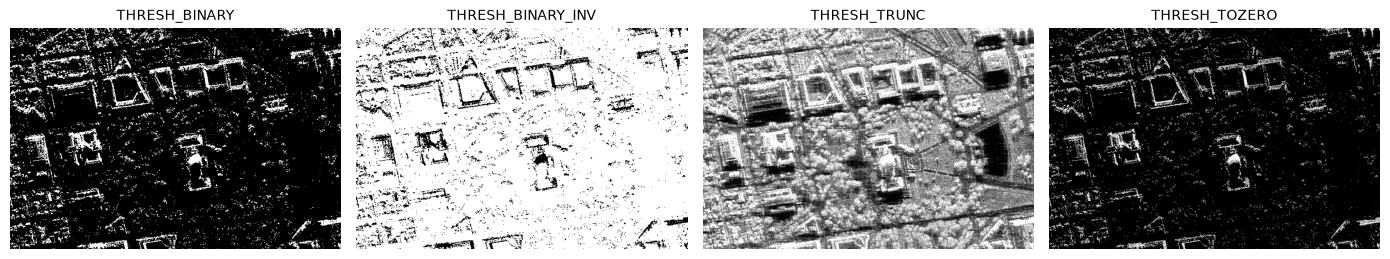

In [7]:
# Задаем порог (например, 127)
thresh_value = 127

# Разные типы пороговой фильтрации
_, th_binary = cv2.threshold(sar_gray, thresh_value, 255, cv2.THRESH_BINARY)
_, th_binary_inv = cv2.threshold(sar_gray, thresh_value, 255, cv2.THRESH_BINARY_INV)
_, th_trunc = cv2.threshold(sar_gray, thresh_value, 255, cv2.THRESH_TRUNC)
_, th_tozero = cv2.threshold(sar_gray, thresh_value, 255, cv2.THRESH_TOZERO)

methods = [
    ('THRESH_BINARY', th_binary),
    ('THRESH_BINARY_INV', th_binary_inv),
    ('THRESH_TRUNC', th_trunc),
    ('THRESH_TOZERO', th_tozero)
]

plt.figure(figsize=(14, 4))
for idx, (title, img_th) in enumerate(methods, 1):
    plt.subplot(1, 4, idx)
    plt.imshow(img_th, cmap='gray')
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()